Executive Insights and Visualization

This notebook translates validated data into business insights.

All findings distinguish:
- confirmed descriptive results,
- analytical interpretations,
- data-quality limitations.

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

sns.set_theme(style="whitegrid")

FIGURE_DIR = Path("../outputs/figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

daily = pd.read_csv(
    "C:/cleaned/station_daily_wide.csv",
    encoding="utf-8-sig",
    parse_dates=["service_date"]
)

evidence = pd.read_csv(
    "C:/cleaned/final_evidence_table.csv",
    encoding="utf-8-sig"
)

# Daily trend chart

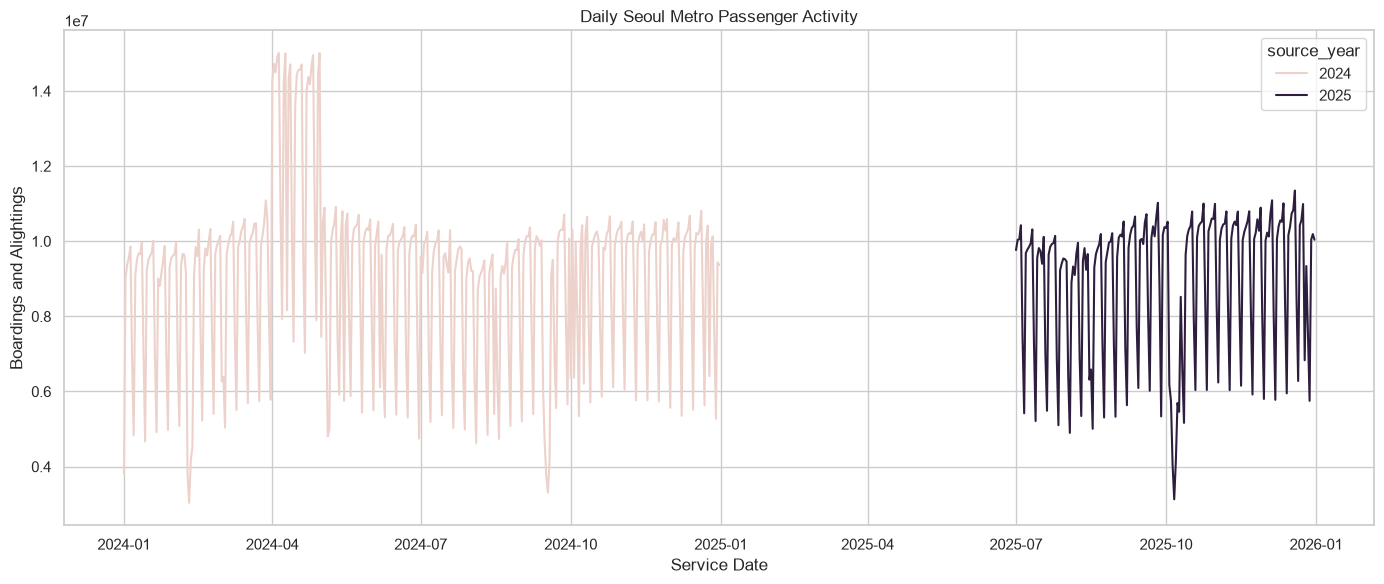

In [6]:
citywide_daily = (
    daily.groupby(["service_date", "source_year"], as_index=False)
    ["total_activity"]
    .sum()
)

plt.figure(figsize=(14, 6))

sns.lineplot(
    data=citywide_daily,
    x="service_date",
    y="total_activity",
    hue="source_year"
)

plt.title("Daily Seoul Metro Passenger Activity")
plt.xlabel("Service Date")
plt.ylabel("Boardings and Alightings")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "daily_citywide_ridership.png",
    dpi=300
)

plt.show()

# Station-function scatterplot

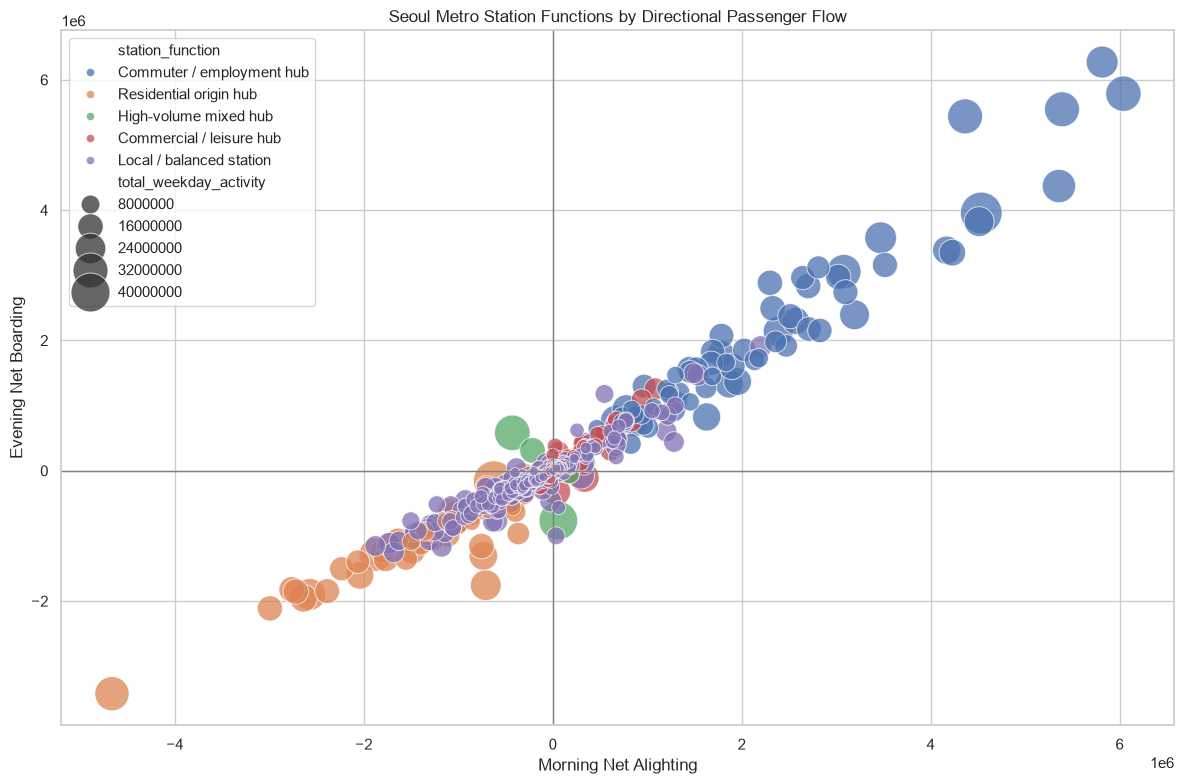

In [7]:
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=evidence,
    x="morning_net_alighting",
    y="evening_net_boarding",
    hue="station_function",
    size="total_weekday_activity",
    sizes=(40, 900),
    alpha=0.75
)

plt.axhline(0, color="gray", linewidth=1)
plt.axvline(0, color="gray", linewidth=1)

plt.title("Seoul Metro Station Functions by Directional Passenger Flow")
plt.xlabel("Morning Net Alighting")
plt.ylabel("Evening Net Boarding")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "station_function_scatterplot.png",
    dpi=300
)

plt.show()

# Classification counts

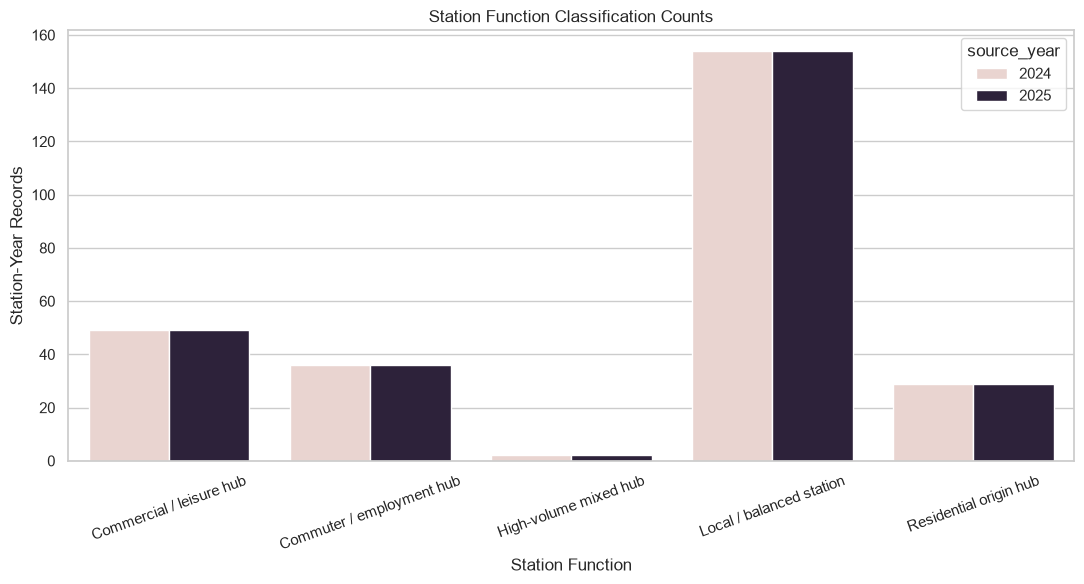

In [9]:
classification_counts = (
    evidence.groupby(
        ["source_year", "station_function"],
        as_index=False
    )
    .size()
    .rename(columns={"size": "station_count"})
)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=classification_counts,
    x="station_function",
    y="station_count",
    hue="source_year"
)

plt.title("Station Function Classification Counts")
plt.xlabel("Station Function")
plt.ylabel("Station-Year Records")
plt.xticks(rotation=20)
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "station_function_counts.png",
    dpi=300
)

plt.show()

# Hourly Demand Analysis



C:\Users\ryanj\AppData\Local\Temp\ipykernel_37112\3891355107.py:87: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Day Type")


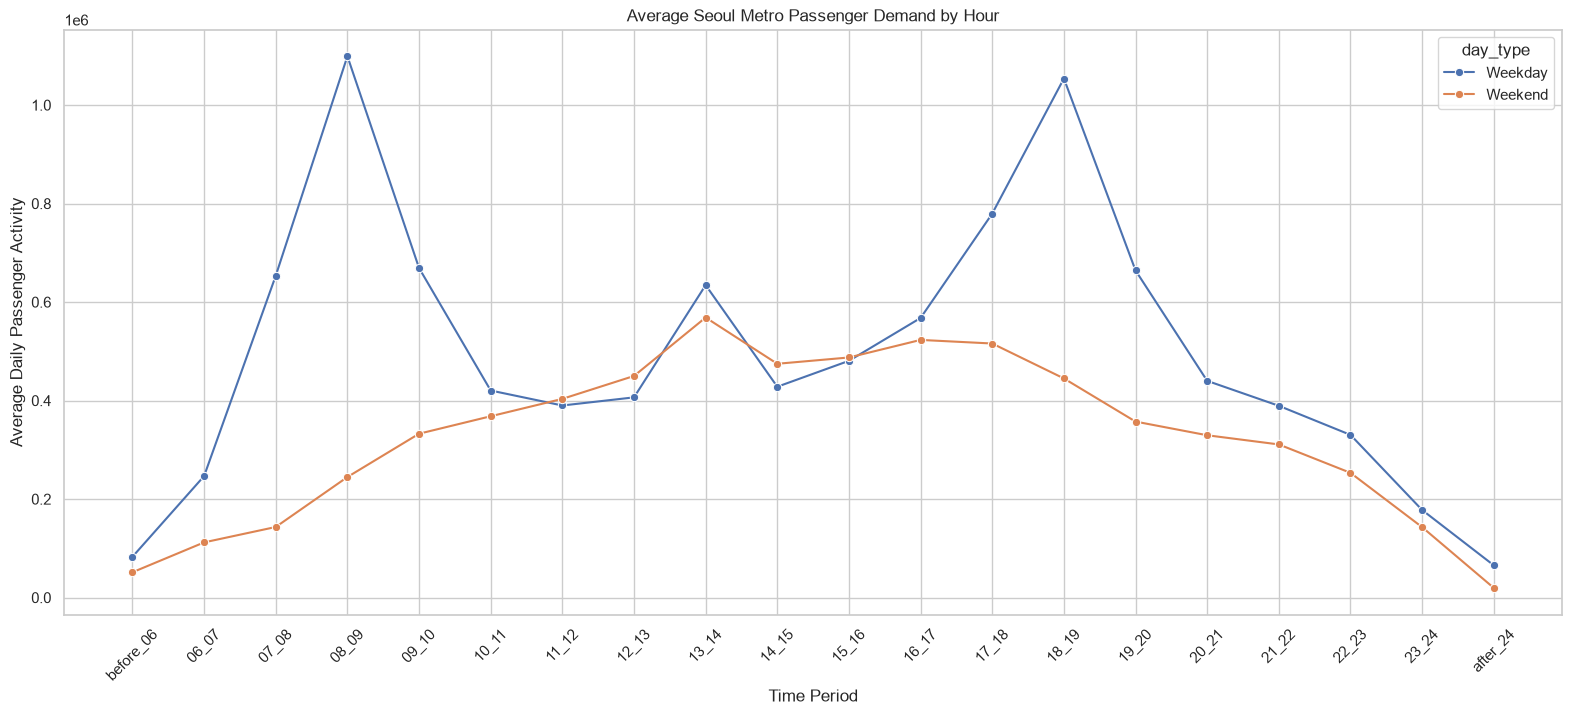

In [25]:

sns.set_theme(style="whitegrid", palette="deep")

# Keep all notebook outputs in the same project folder.
CLEANED_DIR = Path(r"C:\cleaned")
OUTPUT_DIR = FIGURE_DIR

# Load only fields needed for hourly demand visuals.
hourly_total = pd.read_csv(
    CLEANED_DIR / "station_hourly_total.csv",
    encoding="utf-8-sig",
    usecols=[
        "service_date",
        "hour_bucket",
        "passenger_count"
    ],
    parse_dates=["service_date"]
)

# Derive calendar fields directly from the date.
# This avoids relying on potentially inconsistent imported Boolean values.
hourly_total["is_weekday"] = (
    hourly_total["service_date"].dt.dayofweek < 5
)

hourly_total["day_of_week"] = (
    hourly_total["service_date"].dt.day_name()
)

# Set the correct order for the hourly time buckets.
hour_order = [
    "before_06", "06_07", "07_08", "08_09", "09_10",
    "10_11", "11_12", "12_13", "13_14", "14_15",
    "15_16", "16_17", "17_18", "18_19", "19_20",
    "20_21", "21_22", "22_23", "23_24", "after_24"
]

day_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday"
]

# %% [markdown]
# ## Average Hourly Demand: Weekday vs Weekend

# %%
# Calculate total citywide activity for each date and hour.
daily_hourly = (
    hourly_total
    .groupby(
        ["service_date", "hour_bucket", "is_weekday"],
        as_index=False
    )["passenger_count"]
    .sum()
)

# Calculate typical daily demand by hour and day type.
hourly_pattern = (
    daily_hourly
    .groupby(
        ["hour_bucket", "is_weekday"],
        as_index=False
    )["passenger_count"]
    .mean()
)

hourly_pattern["hour_bucket"] = pd.Categorical(
    hourly_pattern["hour_bucket"],
    categories=hour_order,
    ordered=True
)

hourly_pattern["day_type"] = hourly_pattern["is_weekday"].map(
    {
        True: "Weekday",
        False: "Weekend"
    }
)

hourly_pattern = hourly_pattern.sort_values("hour_bucket")

plt.figure(figsize=(16, 7))

plt.title("Average Seoul Metro Passenger Demand by Hour")
plt.xlabel("Time Period")
plt.ylabel("Average Daily Passenger Activity")
plt.xticks(rotation=45)
plt.legend(title="Day Type")
plt.tight_layout()

# Format the y-axis as millions: 2M, 4M, 6M, 8M.
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda value, _: f"{value / 1_000_000:.0f}M")
)
ax.yaxis.set_major_locator(
    MultipleLocator(2_000_000)
)

sns.lineplot(
    data=hourly_pattern,
    x="hour_bucket",
    y="passenger_count",
    hue="day_type",
    marker="o"
)

plt.savefig(
    OUTPUT_DIR / "hourly_demand_weekday_weekend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Heatmap: Average Demand by Day of Week and Hour

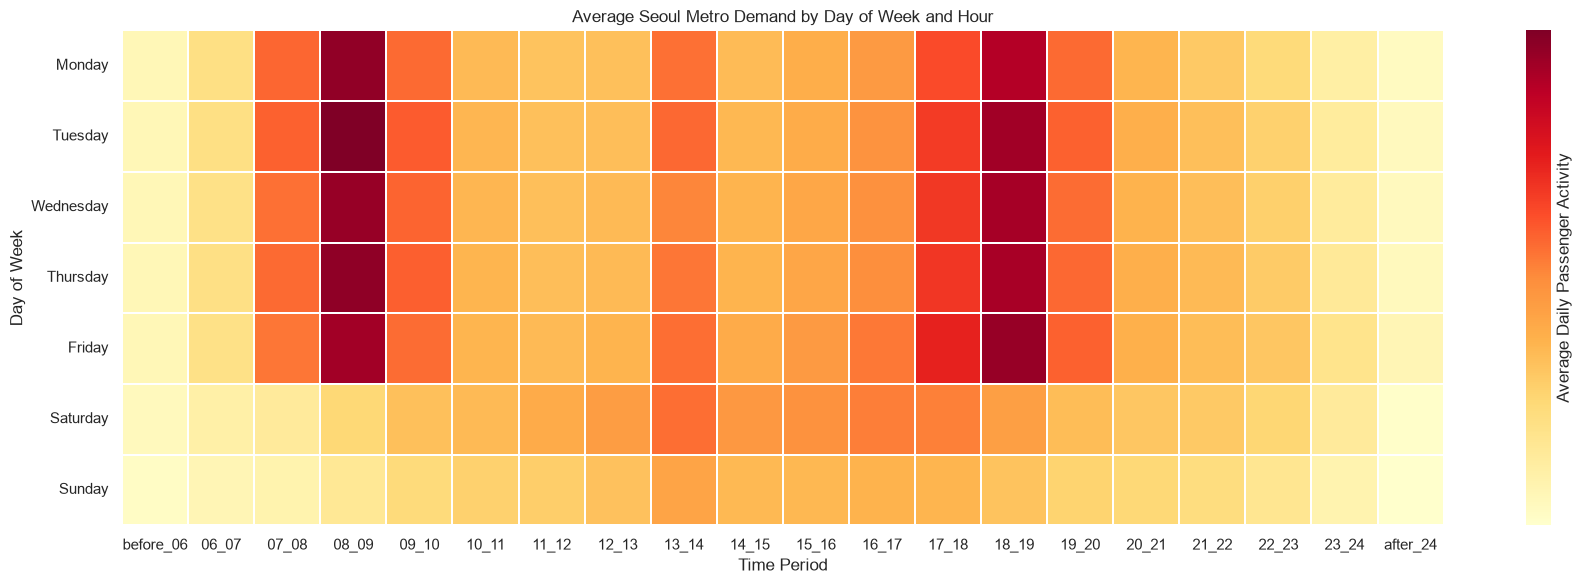

In [26]:
# %% [markdown]
# ## Heatmap: Average Demand by Day of Week and Hour

# %%
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

# Calculate total citywide activity by date, weekday, and hour.
daily_day_hour = (
    hourly_total
    .groupby(
        ["service_date", "day_of_week", "hour_bucket"],
        as_index=False
    )["passenger_count"]
    .sum()
)

# Calculate activity for a typical Monday, Tuesday, etc.
heatmap_data = (
    daily_day_hour
    .groupby(
        ["day_of_week", "hour_bucket"],
        as_index=False
    )["passenger_count"]
    .mean()
)

heatmap_data["day_of_week"] = pd.Categorical(
    heatmap_data["day_of_week"],
    categories=day_order,
    ordered=True
)

heatmap_data["hour_bucket"] = pd.Categorical(
    heatmap_data["hour_bucket"],
    categories=hour_order,
    ordered=True
)

heatmap_matrix = (
    heatmap_data
    .pivot(
        index="day_of_week",
        columns="hour_bucket",
        values="passenger_count"
    )
    .reindex(index=day_order, columns=hour_order)
)

plt.figure(figsize=(18, 6))

ax = sns.heatmap(
    heatmap_matrix,
    cmap="YlOrRd",
    linewidths=0.3,
    cbar_kws={
        "label": "Average Daily Passenger Activity"
    }
)

# Format the heatmap color bar as millions: 2M, 4M, 6M, 8M.
colorbar = ax.collections[0].colorbar

colorbar.ax.yaxis.set_major_formatter(
    FuncFormatter(lambda value, _: f"{value / 1_000_000:.0f}M")
)

colorbar.locator = MultipleLocator(2_000_000)
colorbar.update_ticks()

plt.title("Average Seoul Metro Demand by Day of Week and Hour")
plt.xlabel("Time Period")
plt.ylabel("Day of Week")
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "weekday_hour_demand_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Final Conclusion

Seoul Metro travel is primarily commuter-driven on weekdays, with clear
morning-arrival and evening-departure peaks. 
Employment-oriented stations,
including Gangnam, Yeoksam, Samsung, Seolleung, Seoul Station, Euljiro 1-ga,
and Gasan Digital Complex, show strong destination flows; Sillim,
Sindorim, Seoul National University Entrance, Yeonsinnae, and Suyu show
residential-origin patterns.

Commercial and leisure demand is more sustained through the middle of the day,
especially around Hongik University, Sinchon, Dongdaemun, Dongdaemun History
& Culture Park, and Ewha Womans University. 
The findings are travel-pattern
inferences, not verified land-use labels.